# Carreira e Capacitação — Base SIAPE

Este notebook olha para o bloco de dados "DB_SGC" (Sistema de Gestão de Carreira) e
para a classe/padrão de vencimento. Esses campos só estão preenchidos para uma
parte da base (~23%) — os demais registros aparecem como "NI" porque não fazem
parte desse acompanhamento específico. Este notebook foca no subconjunto que **tem**
essa informação.

Todos os números são agregados — nenhum servidor é identificado individualmente.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))
from src.viz_style import (
    agrupar_celulas_pequenas,
    aplicar_estilo_global,
    grafico_barra_horizontal,
    grafico_top_n_outros,
    resumo_informado,
)

DATA_PATH = Path("../data/raw/DB_SIAPE_processado_20260729.xlsx")
df = pd.read_excel(DATA_PATH, engine="openpyxl")

aplicar_estilo_global()
TOTAL = len(df)

## Carreira (DB_SGC)

**O que mostra**: entre os servidores rastreados nesse sistema, a qual carreira
específica cada um pertence.

23.3% da base (2329 servidores) está rastreada no DB_SGC.


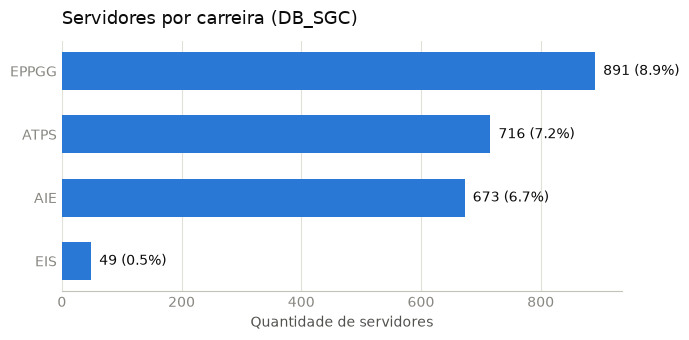

In [2]:
contagem_carreira, pct_carreira = resumo_informado(df["Carreira_DB_SGC"], TOTAL)
print(f"{pct_carreira}% da base ({int(contagem_carreira.sum())} servidores) está rastreada no DB_SGC.")
grafico_barra_horizontal(contagem_carreira, TOTAL, "Servidores por carreira (DB_SGC)", figsize=(7, 3.5))

## Turma (coorte de ingresso)

**O que mostra**: a turma/coorte de ingresso na carreira, entre os servidores com
essa informação. Mostramos as 10 turmas mais numerosas.

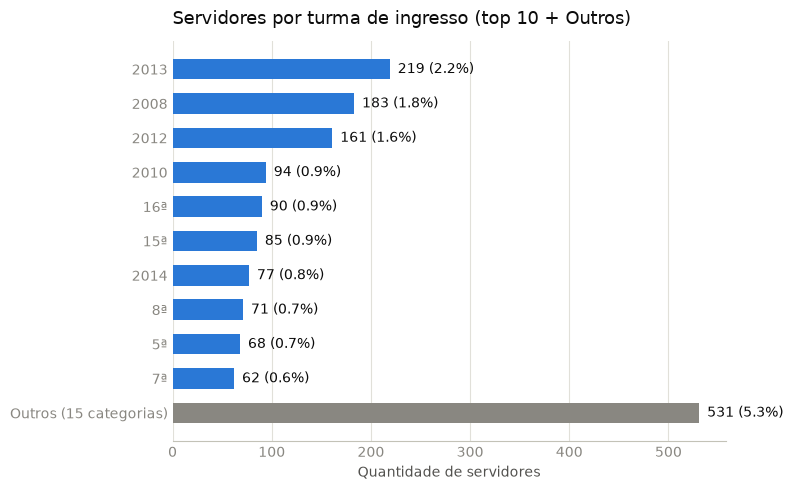

In [3]:
turma_informada = df.loc[df["Turma_DB_SGC"] != "NI", "Turma_DB_SGC"]
_ = grafico_top_n_outros(turma_informada, TOTAL, "Servidores por turma de ingresso (top 10 + Outros)")

## Jornada de trabalho

**O que mostra**: a carga horária semanal registrada, entre os servidores com essa
informação.

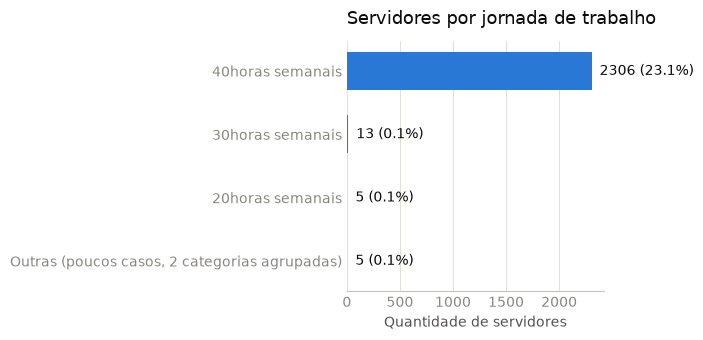

In [4]:
contagem_jornada, _ = resumo_informado(df["Jornada de trabalho_DB_SGC"], TOTAL)
contagem_jornada_protegida, rotulo_jornada_pequena = agrupar_celulas_pequenas(contagem_jornada, minimo=5)
grafico_barra_horizontal(
    contagem_jornada_protegida, TOTAL, "Servidores por jornada de trabalho",
    figsize=(7, 3.5), destacar_neutro=rotulo_jornada_pequena,
)

## Situação funcional (DB_SGC)

**O que mostra**: dentro deste sistema de acompanhamento, quantos servidores estão
em exercício normal, licenciados ou afastados.

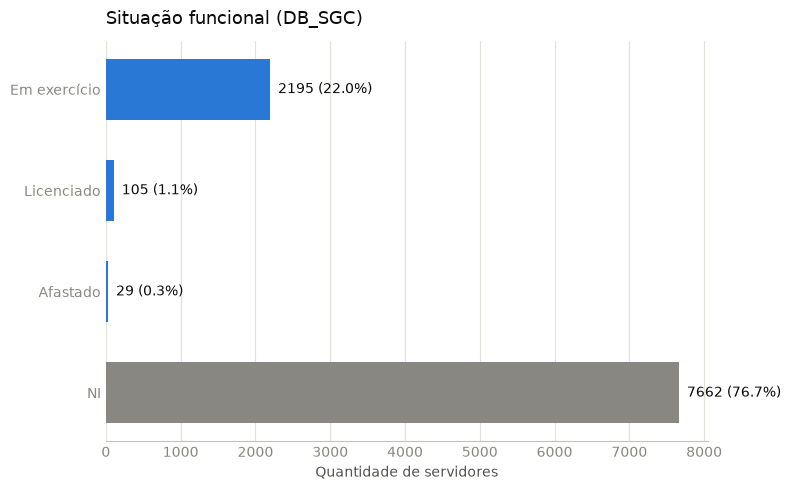

In [5]:
contagem_situacao_funcional = df["Situação funcional_DB_SGC"].value_counts()
grafico_barra_horizontal(
    contagem_situacao_funcional, TOTAL, "Situação funcional (DB_SGC)",
    destacar_neutro="NI",
)

## Tipo de duração do vínculo

**O que mostra**: entre os servidores rastreados, se o vínculo tem prazo
determinado ou indeterminado.

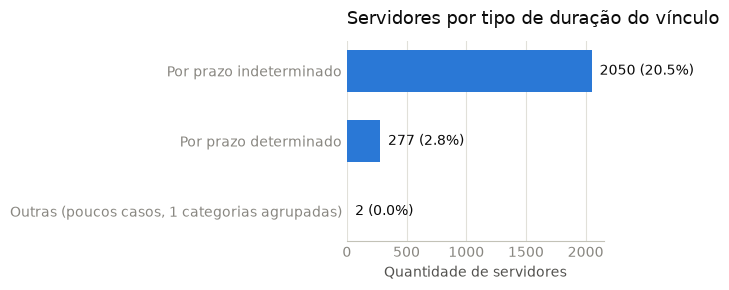

In [6]:
contagem_duracao, _ = resumo_informado(df["Tipo de duração_DB_SGC"], TOTAL)
contagem_duracao_protegida, rotulo_duracao_pequena = agrupar_celulas_pequenas(contagem_duracao, minimo=5)
grafico_barra_horizontal(
    contagem_duracao_protegida, TOTAL, "Servidores por tipo de duração do vínculo",
    figsize=(7, 3), destacar_neutro=rotulo_duracao_pequena,
)

## Classe e Padrão (grade de vencimento)

**O que mostra**: a classe e o padrão salarial dos servidores, entre os que têm
essa informação preenchida (também ~23% da base).

22.7% da base tem classe funcional registrada.


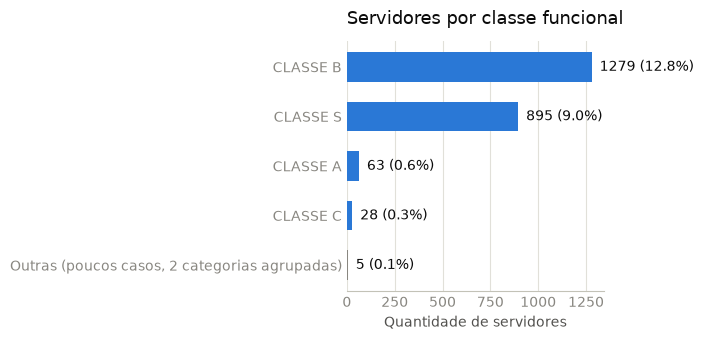

In [7]:
contagem_classe, pct_classe = resumo_informado(df["Classe_Dados pessoais"], TOTAL)
print(f"{pct_classe}% da base tem classe funcional registrada.")

contagem_classe_protegida, rotulo_classe_pequena = agrupar_celulas_pequenas(contagem_classe, minimo=5)
grafico_barra_horizontal(
    contagem_classe_protegida, TOTAL, "Servidores por classe funcional",
    figsize=(7, 3.5), destacar_neutro=rotulo_classe_pequena,
)

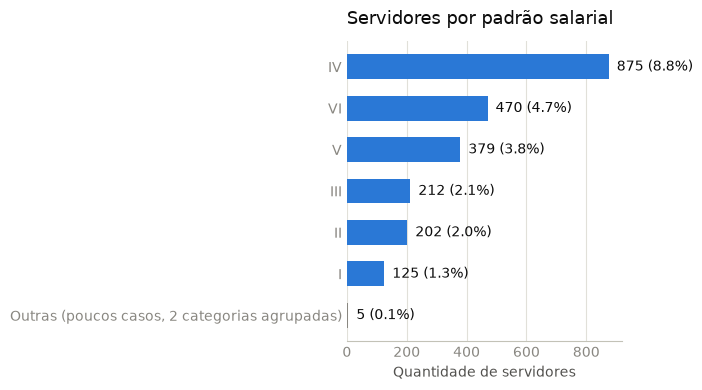

In [8]:
contagem_padrao, _ = resumo_informado(df["Padrão_Dados pessoais"], TOTAL)
contagem_padrao_protegida, rotulo_padrao_pequeno = agrupar_celulas_pequenas(contagem_padrao, minimo=5)
grafico_barra_horizontal(
    contagem_padrao_protegida, TOTAL, "Servidores por padrão salarial",
    figsize=(7, 4), destacar_neutro=rotulo_padrao_pequeno,
)

## Resumo consolidado

In [9]:
from IPython.display import Markdown, display

carreira_predominante = contagem_carreira.idxmax()
pct_carreira_predominante = round(contagem_carreira.max() / TOTAL * 100, 1)
classe_predominante = contagem_classe.idxmax()
pct_classe_predominante = round(contagem_classe.max() / TOTAL * 100, 1)

resumo_md = f"""
- Apenas **{pct_carreira}%** da base tem acompanhamento de carreira registrado no DB_SGC; os demais {round(100 - pct_carreira, 1)}% não fazem parte desse sistema (ex: cargos como Analista Técnico Executivo, que é o cargo mais comum da base, não aparecem aqui).
- Entre os rastreados, a carreira mais comum é **{carreira_predominante}**, com **{pct_carreira_predominante}%** da base total.
- A classe funcional mais comum (entre os informados) é **{classe_predominante}**, com **{pct_classe_predominante}%** da base total.
- A grande maioria dos vínculos rastreados é por prazo indeterminado.

Esses numeros descrevem o quadro como um todo — nenhum servidor especifico foi identificado nesta analise.
"""

display(Markdown(resumo_md))


- Apenas **23.3%** da base tem acompanhamento de carreira registrado no DB_SGC; os demais 76.7% não fazem parte desse sistema (ex: cargos como Analista Técnico Executivo, que é o cargo mais comum da base, não aparecem aqui).
- Entre os rastreados, a carreira mais comum é **EPPGG**, com **8.9%** da base total.
- A classe funcional mais comum (entre os informados) é **CLASSE B**, com **12.8%** da base total.
- A grande maioria dos vínculos rastreados é por prazo indeterminado.

Esses numeros descrevem o quadro como um todo — nenhum servidor especifico foi identificado nesta analise.
